In [6]:
# =============================================================================
# CELL 1 — Monte Carlo GP Assignment Probability: Pilot on Ganganagar District
# =============================================================================

# Purpose:
#   Pilot implementation of Monte Carlo GP assignment probability estimation
#   for NFHS clusters in Ganganagar district, Rajasthan. We start with a small geographic patch to verify the approach
#   by hand before scaling up to all of RJ and UP.
#
# Approach:
#   For each NFHS cluster in Ganganagar:
#   1. Simulate N random displacements using the actual DHS displacement
#      distribution: angle ~ Uniform[0, 2π), distance ~ Uniform[0, R]
#      where R = 5km for rural clusters, 2km for urban
#   2. For each simulated true location, identify which GP it falls in
#   3. Compute the fraction of simulations landing in each GP — this is
#      the estimated probability that the cluster's true location is in
#      that GP
#
#   This is more principled than simple area-overlap weighting because it
#   correctly implements the actual DHS displacement distribution, where
#   closer distances are more likely than the outer edge of the buffer
#   (uniform on distance, not on area).
#
# Note on ALT_DEM:
#   ALT_DEM is recorded at the displaced GPS location
#   (a simple SRTM lookup), not the true cluster location. Ganganagar is
#   flat plains so elevation filtering is not applied in this pilot.
#
# Data requirements:
#   Same as cluster_GPs_cleaning.ipynb — all files in ../data/
#
# Pilot district: Ganganagar, Rajasthan (pc11_d_id = "099")
#   3,034 SHRUG village polygons
#   Rajasthan chosen for pilot due to near-complete LGD coverage (87.6%)

In [3]:
# =============================================================================
# CELL 2 — Imports and Paths
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print(f"geopandas: {gpd.__version__}")
print(f"pandas:    {pd.__version__}")
print(f"numpy:     {np.__version__}")

# ── Relative paths ────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")

RJ_VILLAGES_PATH  = DATA_DIR / "shrug rajasthan village polygons" / "shrug_rajasthan_villages.shp"
NFHS4_GPS_PATH    = DATA_DIR / "nfhs4" / "nfhs4_gps_clusters.shp"
NFHS5_GPS_PATH    = DATA_DIR / "nfhs5" / "nfhs5_gps_clusters.shp"
SHRUG_LGD_PATH    = DATA_DIR / "shrug_LGD_matched.csv"

# ── Constants ─────────────────────────────────────────────────────────────────
PROJECTED_CRS       = "EPSG:32644"   # UTM Zone 44N (metres)
PILOT_DISTRICT      = "099"          # Ganganagar, Rajasthan
PILOT_STATE         = "08"           # Rajasthan
N_SIMULATIONS       = 1000           # Monte Carlo draws per cluster
RURAL_DISPLACEMENT  = 5000           # metres
URBAN_DISPLACEMENT  = 2000           # metres
RANDOM_SEED         = 42             # for reproducibility

# ── Verify files ──────────────────────────────────────────────────────────────
print("\nChecking required files:")
for path in [RJ_VILLAGES_PATH, NFHS4_GPS_PATH, NFHS5_GPS_PATH, SHRUG_LGD_PATH]:
    status = "✓" if path.exists() else "✗ NOT FOUND"
    print(f"  {status}  {path}")

geopandas: 1.1.3
pandas:    3.0.2
numpy:     1.26.4

Checking required files:
  ✓  ../data/shrug rajasthan village polygons/shrug_rajasthan_villages.shp
  ✓  ../data/nfhs4/nfhs4_gps_clusters.shp
  ✓  ../data/nfhs5/nfhs5_gps_clusters.shp
  ✓  ../data/shrug_LGD_matched.csv


In [4]:
# =============================================================================
# CELL 3 — Load and Prepare Ganganagar Village Polygons
# =============================================================================

print("Loading Rajasthan village polygons...")
rj_villages = gpd.read_file(RJ_VILLAGES_PATH)
print(f"Total Rajasthan villages: {len(rj_villages)}")

# Filter to Ganganagar district
ganganagar_villages = rj_villages[
    rj_villages["pc11_d_id"] == PILOT_DISTRICT
].copy()
print(f"Ganganagar villages: {len(ganganagar_villages)}")

# Reproject to metres
ganganagar_villages = ganganagar_villages.to_crs(PROJECTED_CRS)
print(f"CRS: {ganganagar_villages.crs}")
print(f"Columns: {ganganagar_villages.columns.tolist()}")

Loading Rajasthan village polygons...
Total Rajasthan villages: 44976
Ganganagar villages: 3034
CRS: EPSG:32644
Columns: ['pc11_s_id', 'pc11_d_id', 'pc11_sd_id', 'pc11_tv_id', 'tv_name', 'geometry']


In [5]:
# =============================================================================
# CELL 4 — Assign GP Codes to Ganganagar Villages
# =============================================================================

print("Loading SHRUG-LGD crosswalk...")
shrug_lgd = pd.read_csv(SHRUG_LGD_PATH, encoding="latin-1", low_memory=False)

# Build GP code column
def get_gp_code(row):
    if row["gp_to_urban_conversion"] == "Yes" and pd.notna(row["old_gp_lgd_code"]):
        return row["old_gp_lgd_code"]
    elif pd.notna(row["LGD_code"]) and row["local_body_type"] == "Gram Panchayat":
        return row["LGD_code"]
    return None

def get_gp_name(row):
    if row["gp_to_urban_conversion"] == "Yes" and pd.notna(row["old_gp_name"]):
        return row["old_gp_name"]
    elif pd.notna(row["local_body_name"]) and row["local_body_type"] == "Gram Panchayat":
        return row["local_body_name"]
    return None

shrug_lgd["gp_lgd_code"] = shrug_lgd.apply(get_gp_code, axis=1)
shrug_lgd["gp_name"]     = shrug_lgd.apply(get_gp_name, axis=1)

lgd_gp = shrug_lgd[shrug_lgd["gp_lgd_code"].notna()][
    ["shrid2", "gp_lgd_code", "gp_name"]
].copy().rename(columns={"shrid2": "shrid2_key"})

# Build shrid2 key and merge
ganganagar_villages["shrid2_key"] = (
    "11-" +
    ganganagar_villages["pc11_s_id"].astype(str).str.zfill(2)  + "-" +
    ganganagar_villages["pc11_d_id"].astype(str).str.zfill(3)  + "-" +
    ganganagar_villages["pc11_sd_id"].astype(str).str.zfill(5) + "-" +
    ganganagar_villages["pc11_tv_id"].astype(str).str.zfill(6)
)

ganganagar_villages = ganganagar_villages.merge(lgd_gp, on="shrid2_key", how="left")

matched = ganganagar_villages["gp_lgd_code"].notna().mean()
print(f"Villages with GP code: {ganganagar_villages['gp_lgd_code'].notna().sum()} ({matched:.1%})")
print(f"Unique GPs in Ganganagar: {ganganagar_villages['gp_lgd_code'].nunique()}")

Loading SHRUG-LGD crosswalk...
Villages with GP code: 2840 (93.6%)
Unique GPs in Ganganagar: 343


In [7]:
# =============================================================================
# CELL 5 — Dissolve Village Polygons to GP Level
# =============================================================================
# This is the key new step: merging village polygons up to GP boundaries
# by grouping all villages that share the same gp_lgd_code.
# Required for the Monte Carlo — we need to know which GP each
# simulated point falls in.

print("Dissolving village polygons to GP level...")

gp_polygons = (
    ganganagar_villages[ganganagar_villages["gp_lgd_code"].notna()]
    .dissolve(by="gp_lgd_code", as_index=False)
    [["gp_lgd_code", "gp_name", "geometry"]]
)

print(f"GP polygons created: {len(gp_polygons)}")
print(f"Sample GP names:")
print(gp_polygons["gp_name"].head(10).tolist())

# Basic geometry check
invalid = (~gp_polygons.geometry.is_valid).sum()
print(f"\nInvalid geometries: {invalid}")
if invalid > 0:
    print("Fixing invalid geometries with buffer(0)...")
    gp_polygons["geometry"] = gp_polygons.geometry.buffer(0)
    print(f"Invalid after fix: {(~gp_polygons.geometry.is_valid).sum()}")

Dissolving village polygons to GP level...
GP polygons created: 343
Sample GP names:
['2 Kwm', '1 Lsm', '1 Mlk C', '1 Skm B', '10 As', '10 Dol', '10 Kd', '10 Sarkari', '11:00 PM', '11 12 Nd (Nahranwali)']

Invalid geometries: 0


In [8]:
# =============================================================================
# CELL 6 — Load and Filter NFHS Clusters to Ganganagar
# =============================================================================

def load_clusters_for_district(path, round_name, state_code, district_name):
    """
    Load GPS clusters, filter to pilot district using spatial join
    with the GP polygons bounding box.
    """
    print(f"\nLoading {round_name} clusters...")
    gdf = gpd.read_file(path)

    gdf = gdf[["DHSCLUST", "LATNUM", "LONGNUM",
                "URBAN_RURA", "ADM1NAME", "DHSREGNA"]].copy()
    gdf["ADM1NAME"] = gdf["ADM1NAME"].str.strip().str.upper()

    # Drop zero-coordinate clusters
    gdf = gdf[(gdf["LATNUM"] != 0) & (gdf["LONGNUM"] != 0)].copy()

    # Filter to Rajasthan
    gdf = gdf[gdf["ADM1NAME"] == "RAJASTHAN"].copy()

    # Convert to GeoDataFrame and reproject
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf.LONGNUM, gdf.LATNUM),
        crs="EPSG:4326"
    ).to_crs(PROJECTED_CRS)

    # Filter to Ganganagar using spatial join with GP polygons
    ganganagar_bounds = gp_polygons.geometry.union_all().convex_hull
    gdf = gdf[gdf.geometry.within(ganganagar_bounds)].copy()
    gdf["round"] = round_name

    print(f"  {round_name} clusters in Ganganagar: {len(gdf)}")
    print(gdf["URBAN_RURA"].value_counts().to_string())
    return gdf

nfhs4_ganganagar = load_clusters_for_district(
    NFHS4_GPS_PATH, "NFHS4", PILOT_STATE, PILOT_DISTRICT
)
nfhs5_ganganagar = load_clusters_for_district(
    NFHS5_GPS_PATH, "NFHS5", PILOT_STATE, PILOT_DISTRICT
)


Loading NFHS4 clusters...
  NFHS4 clusters in Ganganagar: 54
URBAN_RURA
R    39
U    15

Loading NFHS5 clusters...
  NFHS5 clusters in Ganganagar: 50
URBAN_RURA
R    37
U    13


In [9]:
# =============================================================================
# CELL 7 — Monte Carlo GP Assignment Probability
# =============================================================================
# For each cluster, simulate N random displacements using the actual DHS
# displacement distribution:
#   angle    ~ Uniform[0, 2π)
#   distance ~ Uniform[0, R]  where R = 5km rural, 2km urban
#
# For each simulated true location, identify which GP it falls in.
# The fraction of simulations in each GP = P(true GP = k | observed D).

def run_monte_carlo(clusters, gp_polygons, n_simulations, random_seed):
    """
    Run Monte Carlo GP assignment for a set of clusters.
    Returns DataFrame with GP probability distributions per cluster.
    """
    np.random.seed(random_seed)
    results = []

    print(f"Running Monte Carlo ({n_simulations} simulations per cluster)...")
    print(f"Clusters to process: {len(clusters)}")

    for i, (_, cluster) in enumerate(clusters.iterrows()):
        if i % 10 == 0:
            print(f"  Processing cluster {i+1}/{len(clusters)}...")

        # Displacement radius based on urban/rural
        R = RURAL_DISPLACEMENT if cluster["URBAN_RURA"] == "R" \
            else URBAN_DISPLACEMENT

        # Draw random angles and distances
        # Per DHS README:
        # angle    ~ Uniform[0, 2π)
        # distance ~ Uniform[0, R]
        angles    = np.random.uniform(0, 2 * np.pi, n_simulations)
        distances = np.random.uniform(0, R, n_simulations)

        # Convert to x, y offsets
        x_offsets = distances * np.cos(angles)
        y_offsets = distances * np.sin(angles)

        # Simulated true locations
        cx = cluster.geometry.x
        cy = cluster.geometry.y
        sim_x = cx + x_offsets
        sim_y = cy + y_offsets

        # Create GeoDataFrame of simulated points
        sim_points = gpd.GeoDataFrame(
            {"sim_id": range(n_simulations)},
            geometry=gpd.points_from_xy(sim_x, sim_y),
            crs=PROJECTED_CRS
        )

        # Spatial join: which GP does each simulated point fall in?
        joined = gpd.sjoin(
            sim_points,
            gp_polygons[["gp_lgd_code", "gp_name", "geometry"]],
            how="left",
            predicate="within"
        )

        # Count simulations per GP
        gp_counts = joined["gp_lgd_code"].value_counts()
        n_outside  = joined["gp_lgd_code"].isna().sum()
        n_assigned = n_simulations - n_outside

        # Primary GP (most simulations)
        primary_gp      = gp_counts.index[0] if len(gp_counts) > 0 else None
        primary_gp_prob = gp_counts.iloc[0] / n_simulations if len(gp_counts) > 0 else 0
        n_gps_hit       = len(gp_counts)

        results.append({
            "DHSCLUST":          cluster["DHSCLUST"],
            "URBAN_RURA":        cluster["URBAN_RURA"],
            "DHSREGNA":          cluster["DHSREGNA"],
            "round":             cluster["round"],
            "displacement_R_m":  R,
            "primary_gp":        primary_gp,
            "primary_gp_prob":   round(primary_gp_prob, 4),
            "n_gps_hit":         n_gps_hit,
            "n_outside_any_gp":  n_outside,
            "gp_distribution":   dict(gp_counts),
        })

    return pd.DataFrame(results)

# Run for both rounds
mc_nfhs4 = run_monte_carlo(nfhs4_ganganagar, gp_polygons, N_SIMULATIONS, RANDOM_SEED)
mc_nfhs5 = run_monte_carlo(nfhs5_ganganagar, gp_polygons, N_SIMULATIONS, RANDOM_SEED)

print("\nDone.")

Running Monte Carlo (1000 simulations per cluster)...
Clusters to process: 54
  Processing cluster 1/54...
  Processing cluster 11/54...
  Processing cluster 21/54...
  Processing cluster 31/54...
  Processing cluster 41/54...
  Processing cluster 51/54...
Running Monte Carlo (1000 simulations per cluster)...
Clusters to process: 50
  Processing cluster 1/50...
  Processing cluster 11/50...
  Processing cluster 21/50...
  Processing cluster 31/50...
  Processing cluster 41/50...

Done.


In [10]:
# =============================================================================
# CELL 8 — Summary Statistics
# =============================================================================

def summarise_mc(mc_df, round_name):
    rural = mc_df[mc_df["URBAN_RURA"] == "R"]
    print(f"\n── {round_name} rural clusters in Ganganagar ──")
    print(f"Total clusters:                    {len(rural)}")
    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")
    print(f"Clusters with P > 0.8 (low risk):  {(rural['primary_gp_prob'] > 0.8).sum()} ({(rural['primary_gp_prob'] > 0.8).mean():.1%})")
    print(f"Clusters with P > 0.5:             {(rural['primary_gp_prob'] > 0.5).sum()} ({(rural['primary_gp_prob'] > 0.5).mean():.1%})")
    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Simulations outside any GP:        {rural['n_outside_any_gp'].mean():.1f} avg per cluster")
    print(f"\nP(primary GP) distribution:")
    bins = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())

summarise_mc(mc_nfhs4, "NFHS4")
summarise_mc(mc_nfhs5, "NFHS5")


── NFHS4 rural clusters in Ganganagar ──
Total clusters:                    39
Mean P(primary GP):                0.308
Median P(primary GP):              0.343
Clusters with P > 0.8 (low risk):  0 (0.0%)
Clusters with P > 0.5:             3 (7.7%)
Mean GPs hit per cluster:          6.28
Simulations outside any GP:        297.6 avg per cluster

P(primary GP) distribution:
prob_bin
0-25%      3
25-50%    27
50-75%     3
75-90%     0
>90%       0

── NFHS5 rural clusters in Ganganagar ──
Total clusters:                    37
Mean P(primary GP):                0.330
Median P(primary GP):              0.356
Clusters with P > 0.8 (low risk):  0 (0.0%)
Clusters with P > 0.5:             2 (5.4%)
Mean GPs hit per cluster:          7.19
Simulations outside any GP:        220.9 avg per cluster

P(primary GP) distribution:
prob_bin
0-25%      1
25-50%    29
50-75%     2
75-90%     0
>90%       0


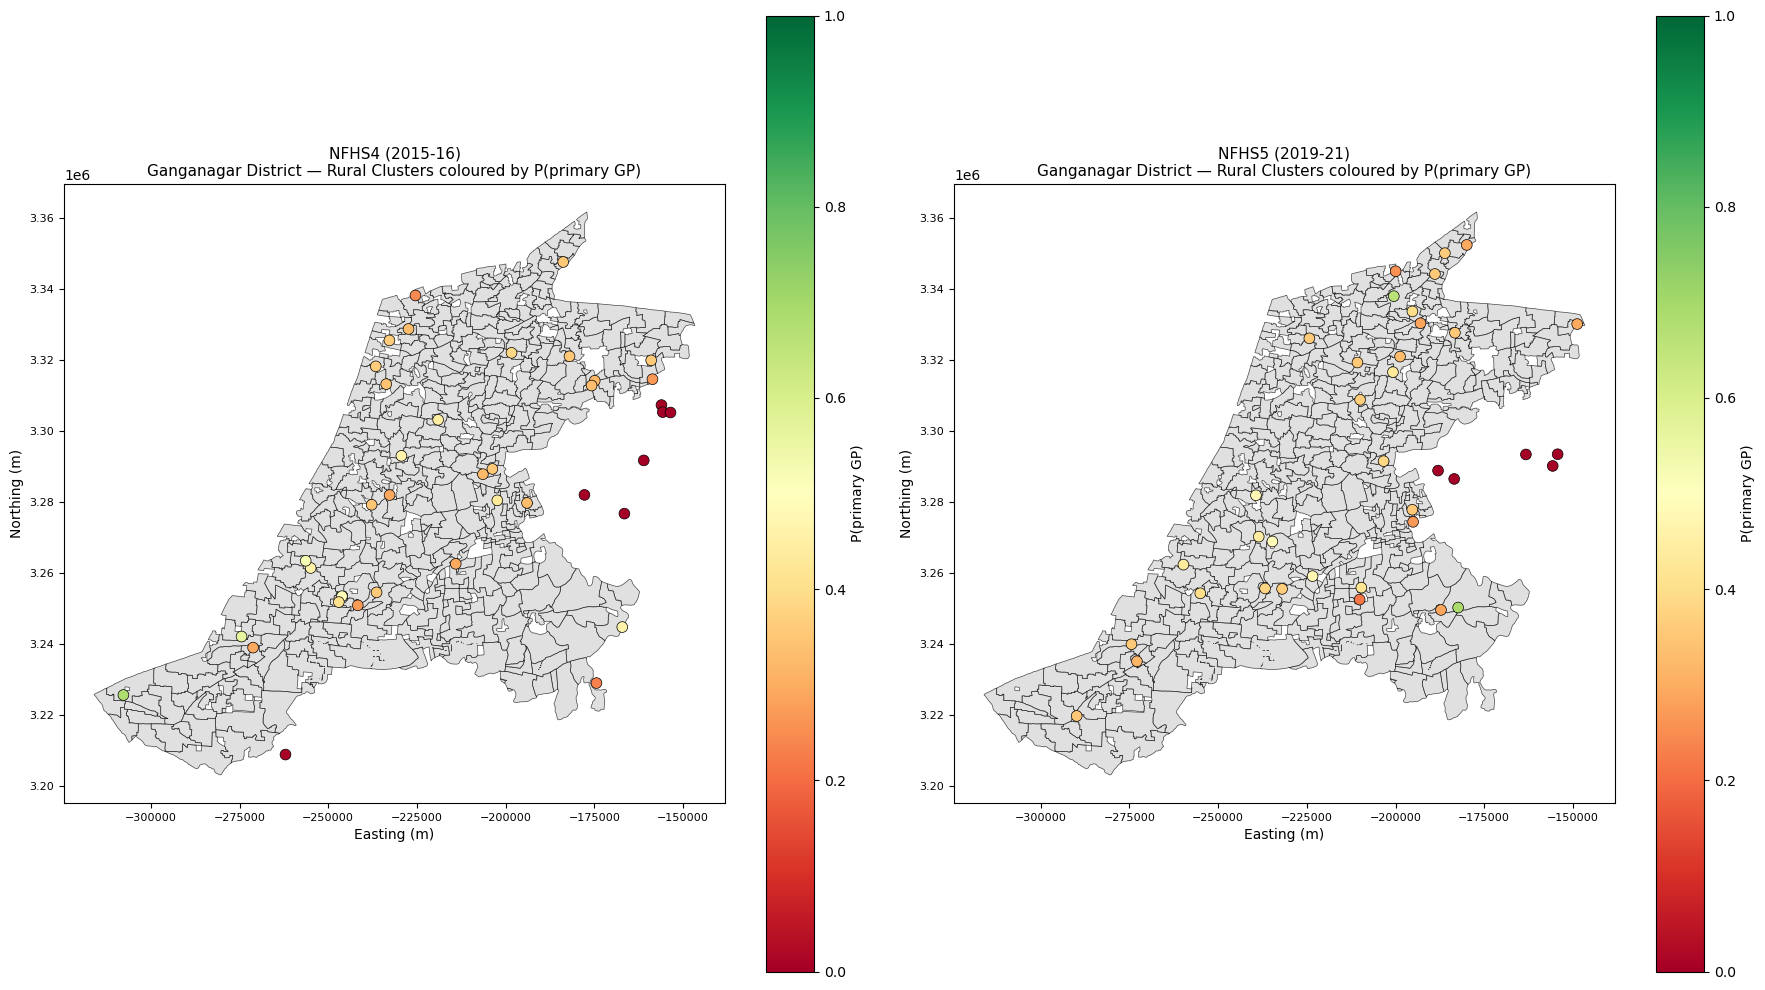

Map saved.


In [11]:
# =============================================================================
# CELL 9 — Visualisation
# =============================================================================
# Plot GP boundaries, cluster locations, and colour clusters by
# P(primary GP) so we can visually verify the Monte Carlo results.

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, mc_df, round_name in [
    (axes[0], mc_nfhs4, "NFHS4 (2015-16)"),
    (axes[1], mc_nfhs5, "NFHS5 (2019-21)")
]:
    # Plot GP boundaries
    gp_polygons.plot(
        ax=ax,
        color="lightgrey",
        edgecolor="black",
        linewidth=0.5,
        alpha=0.7
    )

    # Merge MC results with cluster locations for plotting
    rural_mc = mc_df[mc_df["URBAN_RURA"] == "R"].copy()
    clusters_plot = (
        nfhs4_ganganagar if round_name.startswith("NFHS4")
        else nfhs5_ganganagar
    )
    clusters_plot = clusters_plot[clusters_plot["URBAN_RURA"] == "R"].merge(
        rural_mc[["DHSCLUST", "primary_gp_prob", "n_gps_hit"]],
        on="DHSCLUST", how="left"
    )

    # Colour by P(primary GP)
    scatter = ax.scatter(
        clusters_plot.geometry.x,
        clusters_plot.geometry.y,
        c=clusters_plot["primary_gp_prob"],
        cmap="RdYlGn",
        vmin=0, vmax=1,
        s=60,
        edgecolors="black",
        linewidth=0.5,
        zorder=5
    )

    plt.colorbar(scatter, ax=ax, label="P(primary GP)")
    ax.set_title(f"{round_name}\nGanganagar District — Rural Clusters coloured by P(primary GP)",
                 fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("../data/ganganagar_monte_carlo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Map saved.")

In [12]:
# =============================================================================
# CELL 10 — Hand-Check Sample Clusters
# =============================================================================
# Inspect a few clusters manually to verify
# the Monte Carlo probabilities make intuitive sense.
# We pick clusters spanning the probability range for spot-checking.

def hand_check_cluster(dhsclust, mc_df, clusters_gdf, gp_polygons, n_display=5):
    """Print detailed Monte Carlo results for one cluster."""
    mc_row   = mc_df[mc_df["DHSCLUST"] == dhsclust].iloc[0]
    clust    = clusters_gdf[clusters_gdf["DHSCLUST"] == dhsclust].iloc[0]

    print(f"\n── Cluster {dhsclust} ──────────────────────────────────────")
    print(f"  Location:       ({clust.geometry.x:.0f}, {clust.geometry.y:.0f}) UTM")
    print(f"  Urban/Rural:    {mc_row['URBAN_RURA']}")
    print(f"  District:       {mc_row['DHSREGNA']}")
    print(f"  Displacement R: {mc_row['displacement_R_m']}m")
    print(f"  Primary GP:     {mc_row['primary_gp']} (P = {mc_row['primary_gp_prob']:.1%})")
    print(f"  GPs hit:        {mc_row['n_gps_hit']}")
    print(f"  Sims outside:   {mc_row['n_outside_any_gp']}")
    print(f"\n  GP probability distribution (top {n_display}):")

    gp_dist = mc_row["gp_distribution"]
    for gp_code, count in sorted(gp_dist.items(), key=lambda x: -x[1])[:n_display]:
        gp_name = gp_polygons[gp_polygons["gp_lgd_code"] == gp_code]["gp_name"].values
        name = gp_name[0] if len(gp_name) > 0 else "Unknown"
        prob = count / N_SIMULATIONS
        bar  = "█" * int(prob * 40)
        print(f"    {name:<25} {prob:.1%}  {bar}")

# Pick clusters spanning the probability range
rural_mc4 = mc_nfhs4[mc_nfhs4["URBAN_RURA"] == "R"].sort_values("primary_gp_prob")

high_conf  = rural_mc4.iloc[-1]["DHSCLUST"]   # highest P(primary GP)
mid_conf   = rural_mc4.iloc[len(rural_mc4)//2]["DHSCLUST"]  # median
low_conf   = rural_mc4.iloc[0]["DHSCLUST"]    # lowest P(primary GP)

print("Sample clusters for hand-checking (NFHS4):")
for dhsclust in [high_conf, mid_conf, low_conf]:
    hand_check_cluster(dhsclust, mc_nfhs4, nfhs4_ganganagar, gp_polygons)

Sample clusters for hand-checking (NFHS4):

── Cluster 291105.0 ──────────────────────────────────────
  Location:       (-307752, 3225624) UTM
  Urban/Rural:    R
  District:       Ganganagar
  Displacement R: 5000m
  Primary GP:     262431.0 (P = 68.1%)
  GPs hit:        6
  Sims outside:   56

  GP probability distribution (top 5):
    12 Knd                    68.1%  ███████████████████████████
    17 Knd A                  13.5%  █████
    8 Knd                     6.9%  ██
    7 Knd                     3.5%  █
    13 Dol                    1.2%  

── Cluster 290661.0 ──────────────────────────────────────
  Location:       (-233667, 3313263) UTM
  Urban/Rural:    R
  District:       Ganganagar
  Displacement R: 5000m
  Primary GP:     37780.0 (P = 34.3%)
  GPs hit:        9
  Sims outside:   105

  GP probability distribution (top 5):
    2 Ff A                    34.3%  █████████████
    Motasar Khooni            26.6%  ██████████
    56 F                      11.9%  ████
    Lu

In [14]:
# =============================================================================
# CELL 11 — Save Results
# =============================================================================

mc_nfhs4.to_csv("../data/ganganagar_mc_nfhs4.csv", index=False)
mc_nfhs5.to_csv("../data/ganganagar_mc_nfhs5.csv", index=False)

print("Saved:")
print("  ../data/ganganagar_mc_nfhs4.csv")
print("  ../data/ganganagar_mc_nfhs5.csv")
print(f"\nRows: NFHS4={len(mc_nfhs4)}, NFHS5={len(mc_nfhs5)}")

Saved:
  ../data/ganganagar_mc_nfhs4.csv
  ../data/ganganagar_mc_nfhs5.csv

Rows: NFHS4=54, NFHS5=50
